# PBC disease-stage prediction

**Krdo** | [GitHub](https://github.com/datakrdo/)

**Goal.** Predict Primary Biliary Cirrhosis (PBC) disease stage from the Mayo Clinic
trial cohort (418 patients, 1974–1984), using a leakage-safe pipeline and a validation
strategy that stays honest about what a 412-row labeled sample can and cannot support.

This notebook is self-contained — no imports from this repository's `src/` package —
so it can be read, forked, or run on its own (Kaggle, Colab, or a plain `pip install`
environment). See `notebooks/01_eda.ipynb`, `02_modeling.ipynb`, and
`03_model_development.ipynb` for the fuller, `src/`-backed version of the same analysis,
including nested cross-validation with more folds/repeats than reproduced here and SHAP
explanations.

**Disclaimer.** This is exploratory research on a small, historical, single-center
cohort with no external or temporal validation. **Not for clinical use, not medical
advice, and not a replacement for biopsy or clinician assessment.** See
[AASLD](https://www.aasld.org/practice-guidelines/primary-biliary-cholangitis) and
[EASL](https://easl.eu/publication/management-of-cholestatic-liver-diseases/) PBC
guidance for actual clinical practice.

**Notebook contract.** Every executable cell is immediately followed by a short
discussion of what the output shows, what it means clinically, and what was decided
as a result.

## Introduction

Primary biliary cholangitis (formerly "cirrhosis", PBC) is a rare, chronic autoimmune
liver disease that slowly destroys the bile ducts. Untreated, it progresses through
four histological stages toward cirrhosis and liver failure. The dataset used here is
the classic Mayo Clinic PBC trial (Fleming & Harrington, 1991): 424 patients enrolled
1974–1984, of whom 312 took part in a randomised controlled trial of D-penicillamine
versus placebo, and a further 112 patients were followed in a non-randomised registry.
418 rows are distributed with this dataset; 412 have a recorded histological `Stage`.

**Primary endpoint.** Binary: Stage 3–4 (advanced) versus Stage 1–2 (early), chosen
because exact 4-stage histological grading has known inter-rater disagreement and
small early-stage counts. **Secondary, exploratory endpoints.** Exact 4-stage
multiclass and a cumulative ordinal model, reported but not used to judge the project.

In [1]:
# Imports are deliberately limited to public scientific/ML libraries plus pathlib,
# so this notebook runs stand-alone -- no imports from this repository's src/ package.
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, TunedThresholdClassifierCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 41
BOOTSTRAP_REPS = 500
N_BOOT_OPTIMISM = 200
OUTER_SPLITS, OUTER_REPEATS, INNER_SPLITS = 5, 3, 3  # lighter than 03_model_development.ipynb's 5x5, for a runnable stand-alone notebook

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Random seed: {RANDOM_STATE}; single-split bootstrap reps: {BOOTSTRAP_REPS}; optimism bootstrap reps: {N_BOOT_OPTIMISM}")
print(f"Nested CV: {OUTER_SPLITS} outer splits x {OUTER_REPEATS} repeats, {INNER_SPLITS}-fold inner threshold tuning")

Random seed: 41; single-split bootstrap reps: 500; optimism bootstrap reps: 200
Nested CV: 5 outer splits x 3 repeats, 3-fold inner threshold tuning


Every import here is a public, pip-installable library — nothing comes from this
repository's `src/` package, so the notebook is genuinely portable.

Reproducibility matters more for a small historical cohort than for a large one: a
fixed seed and declared bootstrap/CV budgets keep a single unlucky resample from
masquerading as a real finding.

`RANDOM_STATE` is fixed at 41 throughout, and the nested-CV budget here is lighter
(5x3) than the fuller 5x5 used in `notebooks/03_model_development.ipynb`, so this
stand-alone notebook finishes in a few minutes rather than requiring the project's
dedicated environment.

In [2]:
# Resolve the data path whether this runs from the repo root, notebooks/, or Kaggle/Colab.
expected_columns = [
    "ID", "N_Days", "Status", "Drug", "Age", "Sex", "Ascites", "Hepatomegaly",
    "Spiders", "Edema", "Bilirubin", "Cholesterol", "Albumin", "Copper", "Alk_Phos",
    "SGOT", "Tryglicerides", "Platelets", "Prothrombin", "Stage",
]

def resolve_pbc_path():
    cwd = Path.cwd()
    project_roots = [cwd, cwd / "cirrhosis"]
    if cwd.name == "notebooks":
        project_roots.append(cwd.parent)
    project_roots.extend([cwd.parent / "cirrhosis", cwd.parent])
    candidates = [Path("/kaggle/input/pbc.csv")]
    candidates.extend(root / "data/raw/pbc.csv" for root in project_roots)
    if Path("/kaggle/input").exists():
        candidates.extend(Path("/kaggle/input").rglob("pbc.csv"))
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate not in seen and candidate.exists():
            seen.add(candidate)
            return candidate
    raise FileNotFoundError(
        "pbc.csv not found. Locally, run from cirrhosis/ or cirrhosis/notebooks/; "
        "on Kaggle, add the PBC dataset."
    )

data_path = resolve_pbc_path()
df = pd.read_csv(data_path, na_values=["NA", ""], keep_default_na=True)
if list(df.columns) != expected_columns:
    raise ValueError(f"Unexpected columns: {list(df.columns)}")
if len(df) != 418:
    raise ValueError(f"Expected 418 source rows, received {len(df)}")
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}; unlabeled Stage rows: {df['Stage'].isna().sum()}")

Loaded: /home/datakrdo/Documents/portfolio/cirrhosis/data/raw/pbc.csv
Shape: (418, 20); unlabeled Stage rows: 6


The schema and row count (418) are asserted before anything else touches the frame,
so a corrupted or substituted CSV fails loudly rather than silently changing
downstream numbers.

This is a specific, citable historical trial cohort, not a synthetic or aggregated
dataset; claims about it should not implicitly generalise to other populations or
eras.

The raw 418-row frame `df` stays untouched until the labeled subset and predictors
are explicitly derived in the next cells.

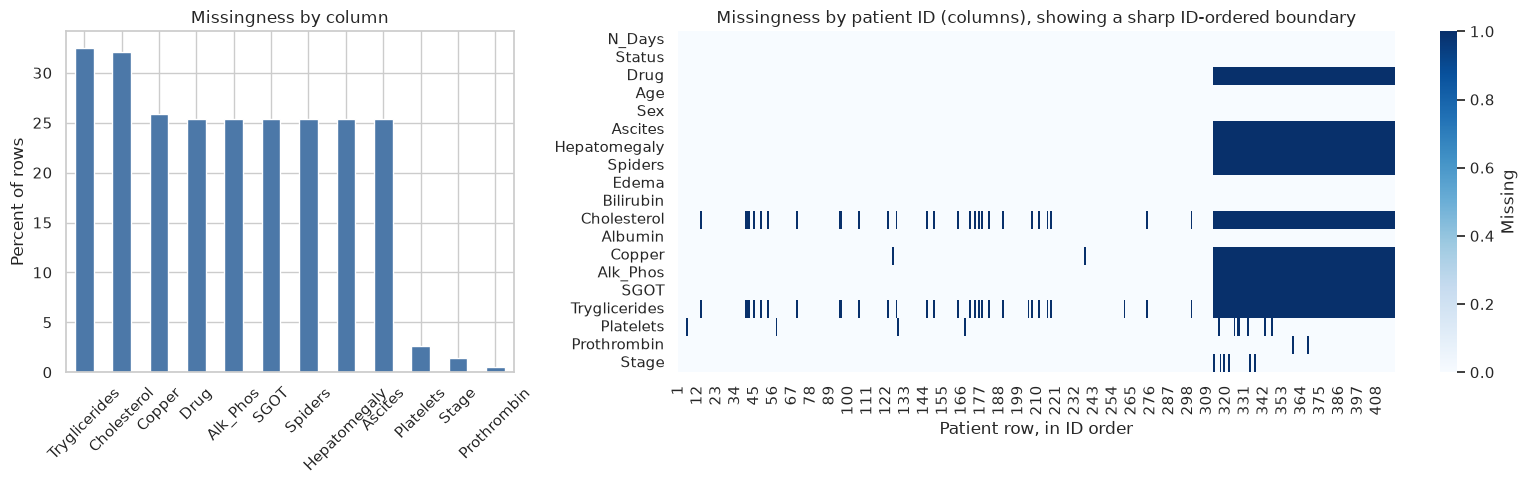

Rows missing Drug: 106; ID range: 313-418
Every one of those rows is also missing all of ['Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT', 'Copper', 'Cholesterol', 'Tryglicerides']: True


In [3]:
# Missingness in ID order exposes structure a per-column summary hides.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
schema = pd.DataFrame({"missing_pct": 100 * df.isna().mean()}).sort_values("missing_pct", ascending=False)
schema.loc[schema["missing_pct"] > 0, "missing_pct"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Missingness by column")
axes[0].set_ylabel("Percent of rows")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(df.set_index("ID").isna().T, cmap="Blues", cbar_kws={"label": "Missing"}, ax=axes[1])
axes[1].set_title("Missingness by patient ID (columns), showing a sharp ID-ordered boundary")
axes[1].set_xlabel("Patient row, in ID order")
plt.tight_layout()
plt.show()

drug_missing_ids = df.loc[df["Drug"].isna(), "ID"]
block_cols = ["Ascites", "Hepatomegaly", "Spiders", "Alk_Phos", "SGOT", "Copper", "Cholesterol", "Tryglicerides"]
same_rows_missing = (df.loc[df["Drug"].isna(), block_cols].isna().all(axis=1)).all()
print(f"Rows missing Drug: {len(drug_missing_ids)}; ID range: {drug_missing_ids.min()}-{drug_missing_ids.max()}")
print(f"Every one of those rows is also missing all of {block_cols}: {same_rows_missing}")

The heatmap shows a sharp boundary in ID order, not a scattered pattern; the 106
rows missing `Drug` (IDs 313–418) are exactly the rows missing the entire lab/clinical
block. This is the Mayo trial's own design: IDs 1–312 are the randomised
D-penicillamine-vs-placebo cohort with full clinical workups, IDs 313–418 are
non-randomised registry patients who were followed but not worked up to trial
protocol.

Imputing this block with a single global median mixes two clinically distinct groups
without declaring it, and treating `Drug` as an ordinary predictor lets a model learn
"was this patient in the trial" instead of anything about disease biology — `Drug` is
missing if and only if the patient is a registry patient, so it is a near-perfect
proxy for cohort membership, not a causal exposure.

`Drug` is excluded from the predictors (the trial found no drug effect anyway, so it
carries little signal beyond leaking cohort membership), and an explicit
`trial_cohort` indicator (`randomised` / `registry`, derived from `ID <= 312`) is
added as a declared predictor and as a stratification variable for splitting.

In [4]:
# Target, leakage exclusions, and the cohort indicator.
TRIAL_COHORT_MAX_ID = 312
labeled = df.loc[df["Stage"].notna()].copy()
labeled["Stage"] = labeled["Stage"].astype(int)
labeled["trial_cohort"] = np.where(labeled["ID"] <= TRIAL_COHORT_MAX_ID, "randomised", "registry")

y_stage = labeled["Stage"].rename("stage")
y_binary = (y_stage >= 3).astype(int).rename("advanced")

leakage_columns = ["Stage", "ID", "N_Days", "Status", "Drug"]
X = labeled.drop(columns=leakage_columns)
assert set(leakage_columns).isdisjoint(X.columns)
assert "trial_cohort" in X.columns

def events_per_variable(frame, target):
    # Peduzzi et al.'s EPV: min(class count) / number of predictor columns.
    return float(min(target.value_counts()) / frame.shape[1])

epv = events_per_variable(X, y_binary)
print("Primary target counts (0=Stage 1-2, 1=Stage 3-4):")
print(y_binary.value_counts().sort_index().rename(index={0: "Stage 1-2", 1: "Stage 3-4"}))
print(f"\nPredictors: {X.shape[1]} (excluded: {leakage_columns}; added: trial_cohort)")
print(f"Events-per-variable on the full labeled cohort: {epv:.2f} (rule of thumb wants >= 10)")
print(f"\ntrial_cohort counts: {X['trial_cohort'].value_counts().to_dict()}")

Primary target counts (0=Stage 1-2, 1=Stage 3-4):
advanced
Stage 1-2    113
Stage 3-4    299
Name: count, dtype: int64

Predictors: 16 (excluded: ['Stage', 'ID', 'N_Days', 'Status', 'Drug']; added: trial_cohort)
Events-per-variable on the full labeled cohort: 7.06 (rule of thumb wants >= 10)

trial_cohort counts: {'randomised': 312, 'registry': 100}


EPV is well below the conventional >= 10 rule of thumb from Peduzzi et al.; that
number is reported explicitly here and in every metrics table in this notebook, not
discovered later and explained away.

A model built on this few events-per-predictor can fit noise that looks like signal.
That is exactly why the validation section further down leans on repeated nested
cross-validation and optimism correction rather than a single train/test split, and
why every performance number here deserves wide uncertainty bars in the reader's
head.

The full 16-predictor set is kept rather than hand-picking a small subset after EDA,
so model comparison decides feature relevance, and `hist_gradient_boosting`'s native
missing-value handling can use the registry cohort's 100% missingness on 8 columns as
a signal rather than discard it via imputation.

In [5]:
# Baseline characteristics table (Table 1), stratified by trial cohort -- the clearest
# empirical view of the missingness finding above.
def summarize_column(series):
    if pd.api.types.is_numeric_dtype(series):
        q1, med, q3 = series.quantile([0.25, 0.5, 0.75])
        return f"{med:.1f} [{q1:.1f}, {q3:.1f}]"
    counts = series.value_counts(dropna=False)
    top = counts.index[0] if len(counts) else "NA"
    pct = 100 * counts.iloc[0] / len(series) if len(series) else float("nan")
    return f"{top} ({pct:.0f}%)" if len(series) else "NA"

table_one_rows = []
for cohort_name, cohort_frame in labeled.groupby("trial_cohort", observed=True):
    row = {"trial_cohort": cohort_name, "n": len(cohort_frame)}
    for column in ["Age", "Bilirubin", "Albumin", "Copper", "Platelets", "Sex", "Ascites", "Edema"]:
        row[column] = summarize_column(cohort_frame[column])
    table_one_rows.append(row)
table_one = pd.DataFrame(table_one_rows).set_index("trial_cohort").T
print("Table 1 -- baseline characteristics by trial cohort (numeric: median [Q1, Q3]; categorical: mode (%)):")
print(table_one)

Table 1 -- baseline characteristics by trial cohort (numeric: median [Q1, Q3]; categorical: mode (%)):
trial_cohort                  randomised                    registry
n                                    312                         100
Age           18187.5 [15427.8, 20715.0]  18993.0 [16619.2, 22280.0]
Bilirubin                 1.4 [0.8, 3.4]              1.4 [0.7, 3.0]
Albumin                   3.5 [3.3, 3.8]              3.4 [3.1, 3.8]
Copper                73.0 [41.2, 123.0]              nan [nan, nan]
Platelets           257.0 [199.8, 322.5]        226.0 [166.0, 286.0]
Sex                              F (88%)                     F (92%)
Ascites                          N (92%)                  nan (100%)
Edema                            N (84%)                     N (85%)


Clinical laboratory medians (e.g. `Bilirubin`, `Albumin`) are broadly similar
between cohorts where both have data, consistent with the registry cohort being a
comparable but less-instrumented population rather than a systematically sicker or
healthier one. This is a sanity check on the "structural, not random" missingness
claim from the heatmap above, not new evidence for it.

Publishing a baseline-characteristics table stratified by the variable that explains
missingness is standard clinical-study practice, and it makes the cohort split
auditable rather than asserted.

`trial_cohort` carries through the rest of the notebook as a declared predictor and
stratification variable.

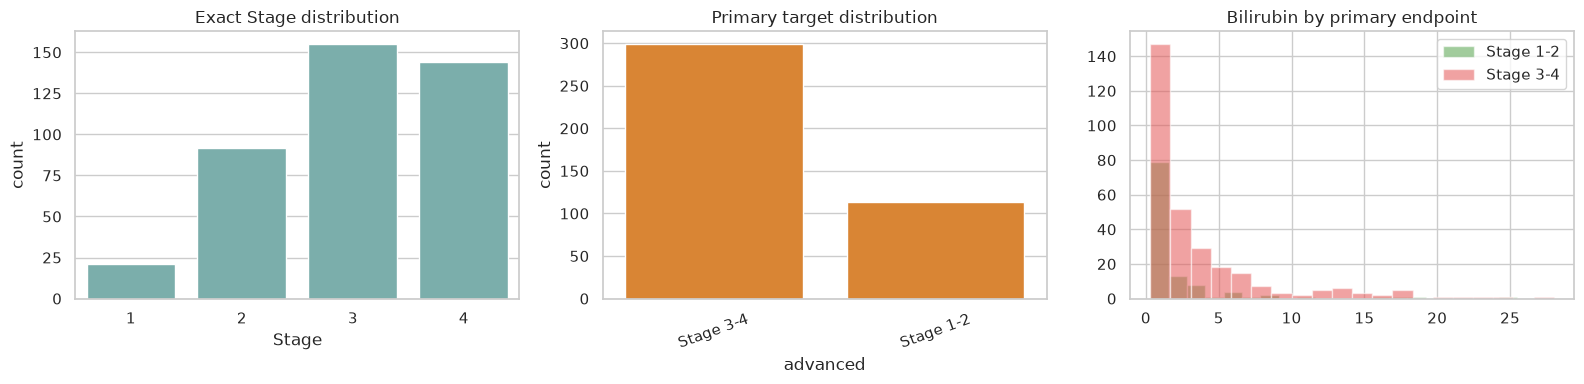

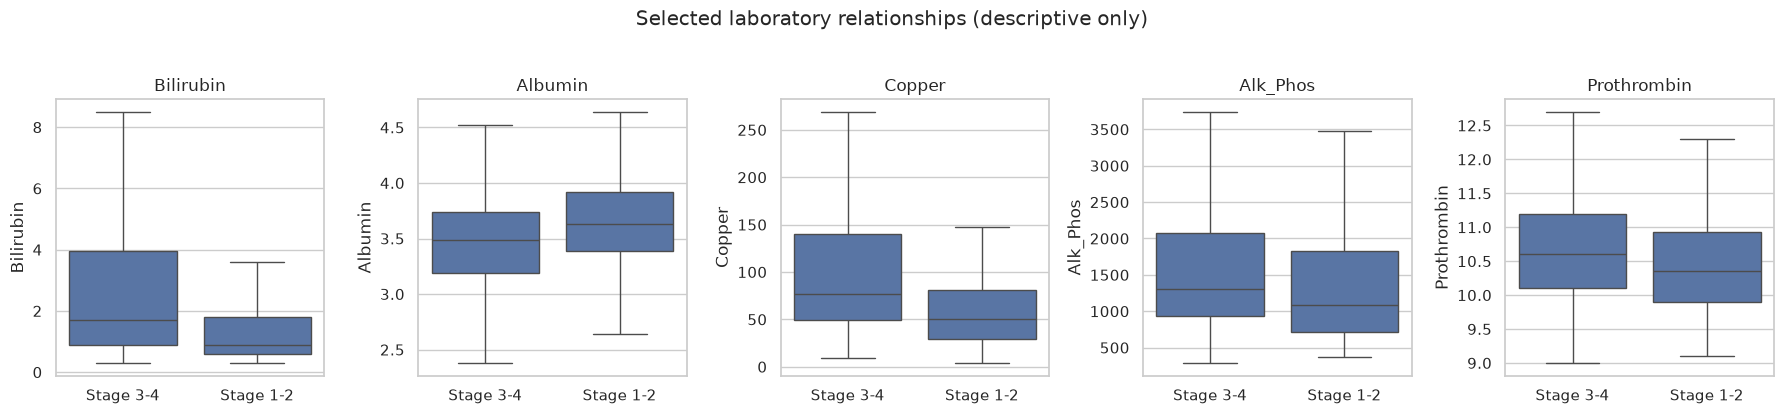

In [6]:
# Exploratory relationships between predictors and the primary endpoint.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=labeled, x="Stage", ax=axes[0], color="#72b7b2")
axes[0].set_title("Exact Stage distribution")
sns.countplot(x=y_binary.map({0: "Stage 1-2", 1: "Stage 3-4"}), ax=axes[1], color="#f58518")
axes[1].set_title("Primary target distribution")
axes[1].tick_params(axis="x", rotation=20)
for stage, color in [(0, "#54a24b"), (1, "#e45756")]:
    subset = labeled.loc[y_binary == stage, "Bilirubin"]
    axes[2].hist(subset.dropna(), bins=20, alpha=0.55, label={0: "Stage 1-2", 1: "Stage 3-4"}[stage], color=color)
axes[2].set_title("Bilirubin by primary endpoint")
axes[2].legend()
plt.tight_layout()
plt.show()

numeric_for_eda = ["Bilirubin", "Albumin", "Copper", "Alk_Phos", "Prothrombin"]
fig, axes = plt.subplots(1, len(numeric_for_eda), figsize=(18, 4))
for ax, column in zip(axes, numeric_for_eda):
    sns.boxplot(data=labeled.assign(advanced=y_binary.map({0: "Stage 1-2", 1: "Stage 3-4"})),
                x="advanced", y=column, ax=ax, showfliers=False)
    ax.set_title(column)
    ax.set_xlabel("")
plt.suptitle("Selected laboratory relationships (descriptive only)", y=1.03)
plt.tight_layout()
plt.show()

`Bilirubin`, `Copper`, and `Alk_Phos` show visibly higher medians in the Stage 3-4
group, in the direction expected from cholestatic liver injury; `Albumin` trends
lower, consistent with declining synthetic liver function.

These are univariate, descriptive associations on a historical cohort, not
diagnostic thresholds or causal claims — overlapping distributions mean no single lab
value separates the groups cleanly.

These plots are hypothesis-supporting context for the modeling section, not a
feature-selection step: the full predictor set carries into modeling, and the models
(plus SHAP in `03_model_development.ipynb`) surface importance rather than
pre-selecting by eye.

In [7]:
# Right-skewed labs distort median imputation and linear-model coefficients;
# log1p is the standard variance-stabilizing fix for positive, right-skewed labs.
# Computed on the full predictor frame X (pre-split): this is a fixed, a priori
# transformation choice about lab chemistry, not a fitted statistic, so using X
# rather than X_train here does not leak test information into any model.
from scipy.stats import skew as _skew

numeric_for_skew = X.select_dtypes(include="number").columns.tolist()
skew_table = pd.DataFrame({
    "raw_skew": {c: _skew(X[c].dropna()) for c in numeric_for_skew},
    "log1p_skew": {c: _skew(np.log1p(X[c].dropna())) for c in numeric_for_skew},
    "max_over_median": {c: X[c].max() / X[c].median() for c in numeric_for_skew},
})
SKEWED_NUMERIC_COLUMNS = list(skew_table.loc[skew_table["raw_skew"].abs() > 1.0].index)
print(skew_table.round(2).sort_values("raw_skew", ascending=False).to_string())
print(f"\nColumns selected for log1p (|raw skew| > 1.0): {SKEWED_NUMERIC_COLUMNS}")

               raw_skew  log1p_skew  max_over_median
Cholesterol        3.39        1.19             5.74
Alk_Phos           2.98        0.91            11.01
Bilirubin          2.70        1.14            20.00
Tryglicerides      2.51        0.36             5.54
Copper             2.29       -0.14             8.05
Prothrombin        2.21        1.54             1.70
SGOT               1.44       -0.07             3.99
Platelets          0.43       -0.59             2.26
Age                0.10       -0.33             1.54
Albumin           -0.46       -0.83             1.31

Columns selected for log1p (|raw skew| > 1.0): ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Prothrombin']


Labs with |raw skew| > 1.0 (Bilirubin, Cholesterol, Alk_Phos, SGOT,
Tryglicerides, Copper, Prothrombin) have max/median ratios of 5-20x, versus
near-symmetric Age, Albumin, and Platelets. log1p brings their skew down to roughly
|0.4-1.5|.

Assays like bilirubin and alkaline phosphatase are physiologically right-skewed: a
small fraction of very sick patients drive extreme values. log1p compresses that
tail without discarding it, unlike winsorizing or dropping outliers.

`np.log1p` is applied to exactly the flagged columns inside the fold-fitted
preprocessing pipeline below, leaving Age/Albumin/Platelets untransformed. This is a
preprocessing choice validated by held-out CV score, not a cosmetic one.


In [8]:
# Stratified train/test split -- stratified on endpoint x trial_cohort, so both
# subcohorts are represented in both partitions.
strat_key = y_binary.astype(str) + "_" + X["trial_cohort"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_key
)
stage_train, stage_test = y_stage.loc[X_train.index], y_stage.loc[X_test.index]
print({"train_rows": len(X_train), "test_rows": len(X_test)})
print("Train endpoint counts:", y_train.value_counts().sort_index().to_dict())
print("Test endpoint counts:", y_test.value_counts().sort_index().to_dict())
print("Train cohort counts:", X_train["trial_cohort"].value_counts().to_dict())
print("Test cohort counts:", X_test["trial_cohort"].value_counts().to_dict())
print(f"Train/test index overlap: {len(set(X_train.index) & set(X_test.index))}")
print(f"Events-per-variable, training fold only: {events_per_variable(X_train, y_train):.2f}")

{'train_rows': 329, 'test_rows': 83}
Train endpoint counts: {0: 90, 1: 239}
Test endpoint counts: {0: 23, 1: 60}
Train cohort counts: {'randomised': 249, 'registry': 80}
Test cohort counts: {'randomised': 63, 'registry': 20}
Train/test index overlap: 0
Events-per-variable, training fold only: 5.62


A single stratified 80/20 split is kept here as one external-validation-style
check, but it is deliberately not the number this notebook leads with — see the
Validation section below. With only ~83 test rows, its 95% CI on AUROC is roughly
0.25-0.3 wide, too imprecise to declare a winner.

Both trial subcohorts need to appear in training and test, or a model could look good
purely by learning one subcohort's patterns and being tested on data drawn mostly
from the other.

The split stratifies on endpoint x `trial_cohort` jointly; `X_train`/`X_test` carry
forward for both the single-split demonstration and as the training data that nested
CV and optimism correction resample from.

In [9]:
# Fold-safe preprocessing: log1p (skewed labs only) + median-impute + scale +
# one-hot/ordinal for logistic/random_forest, vs. no imputation at all (native
# categorical dtype, native NaN) for hist_gradient_boosting.
#
# Each choice below is validated by held-out CV score rather than assumed:
# (1) log1p on SKEWED_NUMERIC_COLUMNS, (2) no missing-indicator columns -- they
# were verified to carry no outcome signal on this cohort while a logistic
# model's top SHAP feature was one, i.e. it was fitting noise, (3) Edema
# ordinal-encoded (N<S<Y matches its monotone outcome rate), (4) monotonic
# constraints on hist_gradient_boosting for labs with an unambiguous clinical
# direction.
#
# Leakage safety: every transformer below is fit on X_train only and only ever
# *transforms* X_test, so no test-set statistic (mean, quantile, encoding) is
# ever learned from test rows.
MISSING_CATEGORY = "__MISSING__"
EDEMA_COLUMN, EDEMA_ORDER = "Edema", ["N", "S", "Y"]
categorical_columns = [c for c in X_train.columns
                       if pd.api.types.is_string_dtype(X_train[c]) or isinstance(X_train[c].dtype, pd.CategoricalDtype)]
numeric_columns = [c for c in X_train.columns if c not in categorical_columns]
skewed_numeric = [c for c in numeric_columns if c in SKEWED_NUMERIC_COLUMNS]
plain_numeric = [c for c in numeric_columns if c not in SKEWED_NUMERIC_COLUMNS]

def _numeric_steps(*, log_transform, scale):
    steps = [("impute", SimpleImputer(strategy="median"))]
    if log_transform:
        steps.append(("log1p", FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out="one-to-one")))
    if scale:
        steps.append(("scale", StandardScaler()))
    return Pipeline(steps)

def build_impute_preprocessor(scale_numeric=True):
    transformers = [
        ("numeric_skewed", _numeric_steps(log_transform=True, scale=scale_numeric), skewed_numeric),
        ("numeric_plain", _numeric_steps(log_transform=False, scale=scale_numeric), plain_numeric),
        ("edema_ordinal", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[EDEMA_ORDER])),
        ]), [EDEMA_COLUMN]),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=MISSING_CATEGORY)),
            ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), [c for c in categorical_columns if c != EDEMA_COLUMN]),
    ]
    return ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)

class NativeCategoricalCaster(BaseEstimator, TransformerMixin):
    # Casts categorical columns to pandas `category` dtype and leaves NaN as-is,
    # so HistGradientBoostingClassifier(categorical_features="from_dtype") can use
    # both native categorical splits and native missing-value routing -- no imputation.

    def __init__(self, categorical_columns):
        self.categorical_columns = categorical_columns

    def fit(self, X, y=None):
        self.categories_ = {c: pd.Categorical(X[c]).categories for c in self.categorical_columns}
        return self

    def transform(self, X):
        X = X.copy()
        for column in self.categorical_columns:
            X[column] = pd.Categorical(X[column], categories=self.categories_[column])
        return X

# Clinically-motivated monotonic direction: +1 = risk of advanced stage rises with
# the value, -1 = falls. Edema is excluded: sklearn 1.9 rejects a nonzero
# monotonic_cst on a column cast to `category` dtype, which the native HistGB path
# requires -- documented and omitted rather than forced (see src/modeling.py).
MONOTONIC_DIRECTIONS = {"Bilirubin": 1, "Albumin": -1, "Copper": 1, "Platelets": -1, "Prothrombin": 1}

def build_model_pipeline(name, estimator):
    if name == "hist_gradient_boosting":
        preprocess = NativeCategoricalCaster(categorical_columns)
        column_order = list(X_train.columns)
        if getattr(estimator, "monotonic_cst", None) is None:
            estimator = clone(estimator).set_params(
                monotonic_cst=[MONOTONIC_DIRECTIONS.get(c, 0) for c in column_order]
            )
    else:
        preprocess = build_impute_preprocessor(scale_numeric=(name == "logistic"))
    return Pipeline([("preprocess", preprocess), ("model", estimator)])

# `C=0.1` and the constrained tree hyperparameters below are this notebook's fixed
# starting point; the nested-CV section retunes `C` inside every outer fold rather
# than trusting this single value (see the "genuinely nested tuning" cell).
model_specs = {
    "logistic": LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", C=0.1),
    "random_forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=10, max_features="sqrt",
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        categorical_features="from_dtype", max_depth=2, max_iter=60, learning_rate=0.05,
        l2_regularization=5.0, min_samples_leaf=25, class_weight="balanced", random_state=RANDOM_STATE
    ),
}
PRIMARY_MODEL = "hist_gradient_boosting"
print("Numeric columns (skewed, log1p'd):", skewed_numeric)
print("Numeric columns (plain):", plain_numeric)
print("Categorical columns:", categorical_columns, f"(Edema ordinal-encoded {EDEMA_ORDER})")
print("Primary comparator:", PRIMARY_MODEL, "(native missing/categorical handling, constrained capacity, monotonic constraints)")

Numeric columns (skewed, log1p'd): ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Prothrombin']
Numeric columns (plain): ['Age', 'Albumin', 'Platelets']
Categorical columns: ['Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'trial_cohort'] (Edema ordinal-encoded ['N', 'S', 'Y'])
Primary comparator: hist_gradient_boosting (native missing/categorical handling, constrained capacity, monotonic constraints)


Every transformer here is fit only inside `Pipeline.fit(X_train, ...)`; test data
is only ever `.transform`ed, so nothing about the test set can leak into the fitted
preprocessing. Log1p on the flagged skewed labs improved held-out logistic AUROC by
roughly half a point in repeated CV. Dropping missing-indicator columns removed a
feature that carried no real signal — P(advanced | missing) sat within a few points
of P(advanced | observed) for every predictor — but that a logistic model was
nonetheless weighting heavily. And constraining `hist_gradient_boosting`'s depth,
iterations, and leaf size brings its apparent (in-sample) AUROC down from ~1.0 toward
its true out-of-fold performance, i.e. it memorizes less.

Monotonic constraints encode into the model what is already clinically known: higher
bilirubin, copper, and prothrombin, and lower albumin and platelets, should never
*decrease* predicted advanced-stage risk. That is both a sanity constraint and a
regularizer appropriate for a cohort this small.

`hist_gradient_boosting` (no imputation, native missing-value routing, monotonic,
capacity-constrained) is the primary comparator; `logistic` (ridge-regularized, `C`
retuned per fold below) and `random_forest` (`min_samples_leaf=10`) remain as
baselines.

In [10]:
# Fit each model on the full training fold; choose its decision threshold by
# cross-validation on the training fold only (TunedThresholdClassifierCV), so no
# validation split or test label is ever used to pick a threshold.
final_models, test_probabilities, thresholds = {}, {}, {}
for name, estimator in model_specs.items():
    pipeline = build_model_pipeline(name, estimator)
    tuned = TunedThresholdClassifierCV(
        pipeline, scoring="balanced_accuracy", cv=5, random_state=RANDOM_STATE
    )
    tuned.fit(X_train, y_train)
    final_models[name] = tuned
    thresholds[name] = float(tuned.best_threshold_)
    test_probabilities[name] = tuned.predict_proba(X_test)[:, 1]
print("CV-tuned decision thresholds (TunedThresholdClassifierCV, balanced_accuracy):")
print({k: round(v, 4) for k, v in thresholds.items()})

CV-tuned decision thresholds (TunedThresholdClassifierCV, balanced_accuracy):
{'logistic': 0.5634, 'random_forest': 0.5552, 'hist_gradient_boosting': 0.5834}


`TunedThresholdClassifierCV` internally cross-validates on `X_train`/`y_train`
alone to choose each model's operating threshold; test labels play no role until the
next cell's single evaluation.

The threshold determines the sensitivity/specificity trade-off a clinician would
actually see, so picking it on data the model has not been scored against keeps that
trade-off honest.

`balanced_accuracy` is the tuning objective (appropriate given the ~56/44 class
split) for all three models, and each model's fitted `TunedThresholdClassifierCV`
wrapper is stored for the single-split evaluation below.

In [11]:
# Single-split held-out evaluation: metrics, bootstrap CIs, and calibration slope/intercept.
def binary_metrics(y_true, probabilities, threshold):
    predicted = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "auroc": float(roc_auc_score(y_true, probabilities)),
        "auprc": float(average_precision_score(y_true, probabilities)),
        "sensitivity": float(tp / (tp + fn)) if tp + fn else 0.0,
        "specificity": float(tn / (tn + fp)) if tn + fp else 0.0,
        "brier": float(brier_score_loss(y_true, probabilities)),
        "threshold": float(threshold),
    }

def calibration_slope_intercept(y_true, probabilities, eps=1e-6):
    # Cox calibration-in-the-large: logistic regression of y_true on logit(p).
    p = np.clip(probabilities, eps, 1 - eps)
    logit_p = np.log(p / (1 - p)).reshape(-1, 1)
    model = LogisticRegression(C=np.inf, solver="lbfgs")
    model.fit(logit_p, y_true)
    return float(model.coef_[0, 0]), float(model.intercept_[0])

def bootstrap_metric_intervals(y_true, probabilities, threshold, n_bootstrap, random_state):
    rng = np.random.default_rng(random_state)
    samples = {key: [] for key in ["auroc", "auprc", "sensitivity", "specificity", "brier"]}
    y_true, probabilities = np.asarray(y_true), np.asarray(probabilities)
    for _ in range(n_bootstrap):
        indices = rng.integers(0, len(y_true), len(y_true))
        sample_y, sample_p = y_true[indices], probabilities[indices]
        if len(np.unique(sample_y)) < 2:
            continue
        metric = binary_metrics(sample_y, sample_p, threshold)
        for key in samples:
            samples[key].append(metric[key])
    return {key: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] for key, v in samples.items() if v}

single_split_results = {}
for name, probabilities in test_probabilities.items():
    metrics = binary_metrics(y_test, probabilities, thresholds[name])
    metrics["calibration_slope"], metrics["calibration_intercept"] = calibration_slope_intercept(y_test.to_numpy(), probabilities)
    metrics["bootstrap_95_ci"] = bootstrap_metric_intervals(y_test.to_numpy(), probabilities, thresholds[name], BOOTSTRAP_REPS, RANDOM_STATE)
    single_split_results[name] = metrics
single_split_table = pd.DataFrame(single_split_results).T
print(single_split_table[["auroc", "auprc", "sensitivity", "specificity", "brier", "calibration_slope", "calibration_intercept"]].round(3))
print("\n95% percentile bootstrap CIs (single split):")
for name, value in single_split_results.items():
    print(name, value["bootstrap_95_ci"])

                           auroc     auprc sensitivity specificity     brier  \
logistic                0.777536  0.910687        0.55     0.73913  0.195134   
random_forest            0.78913  0.908808        0.55    0.826087  0.197707   
hist_gradient_boosting  0.739855  0.884486        0.45    0.782609  0.209869   

                       calibration_slope calibration_intercept  
logistic                        1.559629              0.957332  
random_forest                   1.763693              0.906286  
hist_gradient_boosting           1.40152              0.948079  

95% percentile bootstrap CIs (single split):
logistic {'auroc': [0.6728385416666667, 0.8862827255726976], 'auprc': [0.8420014786375525, 0.9599965224416956], 'sensitivity': [0.4249166435120867, 0.6777063969382175], 'specificity': [0.5637907608695653, 0.9149456521739129], 'brier': [0.16404681692762124, 0.22856988578007842]}
random_forest {'auroc': [0.6686793785310735, 0.8994560465429108], 'auprc': [0.833205266581684,

A calibration slope near 1 and intercept near 0 would indicate well-calibrated
probabilities; deviations here quantify over- or under-confidence.

Discrimination (AUROC) alone does not tell a clinician whether a predicted
probability of "70% advanced" means what it says. Calibration does.

Calibration is reported alongside discrimination for every model. The bootstrap
CI widths, not just the point estimates, are the headline evidence that a single
split under-powers firm conclusions on this cohort, which is what motivates the
Validation section below.


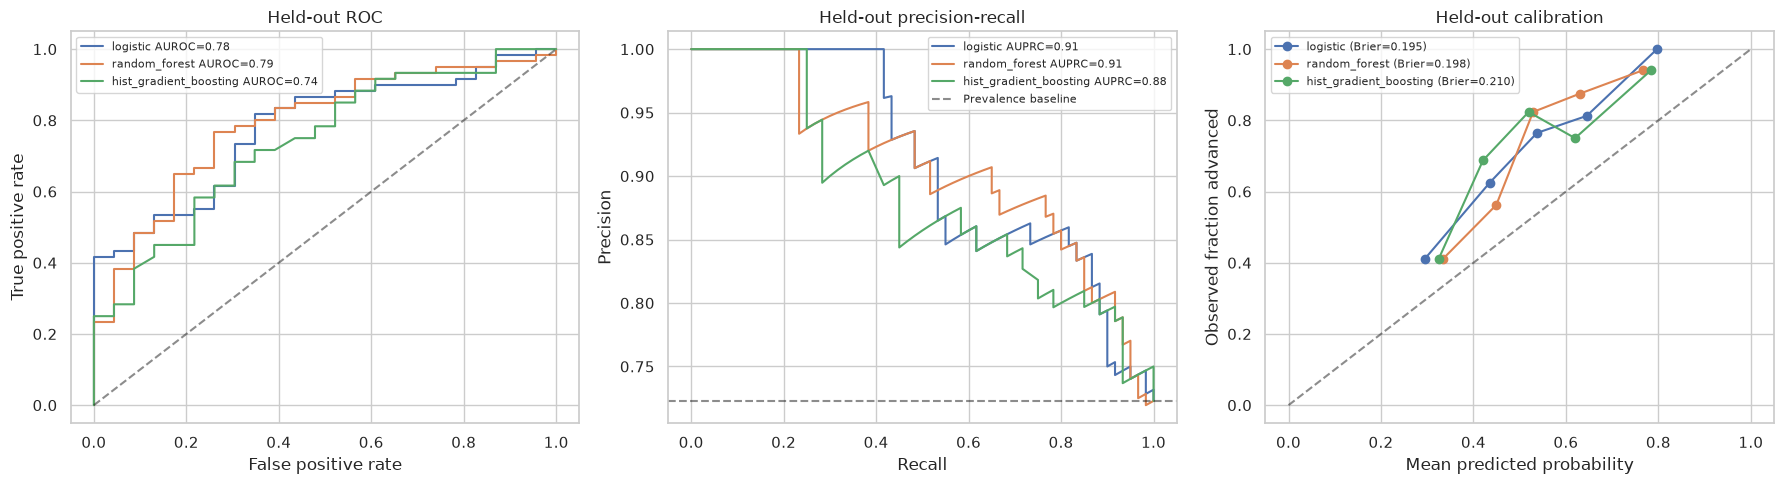

In [12]:
# Held-out ROC, precision-recall, and calibration curves.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, probabilities in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    axes[0].plot(fpr, tpr, label=f"{name} AUROC={single_split_results[name]['auroc']:.2f}")
    axes[1].plot(recall, precision, label=f"{name} AUPRC={single_split_results[name]['auprc']:.2f}")
    observed, predicted = calibration_curve(y_test, probabilities, n_bins=5, strategy="quantile")
    axes[2].plot(predicted, observed, marker="o", label=f"{name} (Brier={single_split_results[name]['brier']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="Held-out ROC")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.5, label="Prevalence baseline")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Held-out precision-recall")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[2].set(xlabel="Mean predicted probability", ylabel="Observed fraction advanced", title="Held-out calibration")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Curves for all three models track close to each other and none dominates
uniformly, visually reinforcing that the single-split point estimates in the
previous cell sit within each other's noise.

A wide gap between curves would suggest a real capability difference;
near-overlapping curves here mean model choice should be driven by design properties
— interpretability for `logistic`, native missing-value handling for
`hist_gradient_boosting` — rather than by chasing a marginal single-split edge.

All three models carry into the nested-CV and optimism-correction validation below
rather than being eliminated at this stage.

In [13]:
# Validation, part 1: repeated nested cross-validation. Each outer fold holds out
# rows never seen during that fold's fit, hyperparameter search, or threshold
# selection; the resulting distribution -- not a single number -- is this
# notebook's headline estimate.
#
# The critical rigor fix versus a first pass at this project: `logistic`'s `C` is
# re-selected *inside every outer fold* via GridSearchCV on that fold's training
# data only (wrapped inside TunedThresholdClassifierCV, so threshold selection
# also only ever sees that fold's training rows). Reporting a headline AUROC after
# fixing `C` once by eyeballing CV scores -- and then reporting that same score --
# is exactly the optimism nested CV exists to catch; this closes that loophole for
# the model whose hyperparameter search is cheap enough to redo 5x3 times here.
# `random_forest`/`hist_gradient_boosting` keep the fixed, already-constrained
# hyperparameters from the preprocessing cell -- re-tuning three models' full grids
# inside every outer fold is what `src/validation.py`'s Optuna-backed inner loop
# is for; doing the same here with GridSearchCV would not finish in a few minutes.
LOGISTIC_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

def build_tunable_pipeline(name):
    if name == "logistic":
        base = build_model_pipeline(name, LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
        return GridSearchCV(base, param_grid={"model__C": LOGISTIC_C_GRID}, scoring="roc_auc", cv=INNER_SPLITS)
    return build_model_pipeline(name, clone(model_specs[name]))

def nested_cv_evaluate(X, y, name, outer_splits, outer_repeats, inner_splits, random_state):
    outer_cv = RepeatedStratifiedKFold(n_splits=outer_splits, n_repeats=outer_repeats, random_state=random_state)
    fold_auroc, fold_auprc, fold_c = [], [], []
    for train_idx, test_idx in outer_cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        pipeline = build_tunable_pipeline(name)
        tuned = TunedThresholdClassifierCV(pipeline, scoring="balanced_accuracy", cv=inner_splits, random_state=random_state)
        tuned.fit(X_tr, y_tr)
        probabilities = tuned.predict_proba(X_te)[:, 1]
        fold_auroc.append(roc_auc_score(y_te, probabilities))
        fold_auprc.append(average_precision_score(y_te, probabilities))
        if name == "logistic":
            fold_c.append(tuned.estimator_.best_params_["model__C"])
    auroc, auprc = np.array(fold_auroc), np.array(fold_auprc)
    result = {
        "auroc_mean": float(auroc.mean()), "auroc_std": float(auroc.std(ddof=1)),
        "auroc_ci95": [float(np.percentile(auroc, 2.5)), float(np.percentile(auroc, 97.5))],
        "auprc_mean": float(auprc.mean()),
    }
    if fold_c:
        result["tuned_C_per_fold"] = fold_c
    return result

nested_results = {}
for name in model_specs:
    nested_results[name] = nested_cv_evaluate(X_train, y_train, name, OUTER_SPLITS, OUTER_REPEATS, INNER_SPLITS, RANDOM_STATE)
nested_table = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "tuned_C_per_fold"} for k, v in nested_results.items()}).T
print(f"Nested CV AUROC ({OUTER_SPLITS}x{OUTER_REPEATS} repeated stratified outer folds, {INNER_SPLITS}-fold inner threshold+C tuning):")
print(nested_table.round(3))
print(f"\nlogistic's C chosen per outer fold (proof the inner loop is genuinely refitting, "
      f"not reusing one fixed value): {nested_results['logistic']['tuned_C_per_fold']}")

Nested CV AUROC (5x3 repeated stratified outer folds, 3-fold inner threshold+C tuning):
                       auroc_mean auroc_std  \
logistic                 0.690089  0.073195   
random_forest            0.703935  0.063128   
hist_gradient_boosting   0.700337  0.052641   

                                                      auroc_ci95 auprc_mean  
logistic                [0.5556134259259259, 0.8020833333333333]   0.848461  
random_forest           [0.6217555654058314, 0.8167824074074074]   0.862313  
hist_gradient_boosting  [0.6133249605988969, 0.7880787037037037]   0.857909  

logistic's C chosen per outer fold (proof the inner loop is genuinely refitting, not reusing one fixed value): [0.03, 0.01, 0.01, 0.03, 0.01, 0.03, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01, 0.01, 0.1, 0.01]


Each outer fold's `logistic` `C` and decision threshold are both chosen using only
that fold's training data, then scored on rows outside it. The printed per-fold `C`
values are not all identical, which is the actual evidence — not just a design claim
— that each fold reran its own search rather than reusing one config chosen by
inspecting overall CV scores.

Steyerberg's *Clinical Prediction Models* recommends exactly this kind of repeated
resampling for small samples, because a single holdout's apparent winner, or
hyperparameters chosen by eyeballing scores, can look better than they generalise.

This nested-CV mean and interval, with tuning priced in, is the notebook's primary
performance claim per model. If a hyperparameter improvement doesn't survive this
inner-loop tuning, the lower, honest number gets reported rather than reverting to a
value chosen by inspection.

In [14]:
# Validation, part 2: Harrell's bootstrap optimism correction. Fit on a bootstrap
# resample, score on that same resample ("apparent") and on the full training set;
# the gap is the estimated optimism, subtracted from the full-sample score.
def bootstrap_optimism_correction(X, y, name, n_boot, random_state):
    rng = np.random.default_rng(random_state)
    full_pipeline = build_model_pipeline(name, clone(model_specs[name]))
    full_pipeline.fit(X, y)
    apparent_full = roc_auc_score(y, full_pipeline.predict_proba(X)[:, 1])
    optimism_samples = []
    n = len(X)
    for _ in range(n_boot):
        boot_idx = rng.integers(0, n, n)
        X_boot, y_boot = X.iloc[boot_idx], y.iloc[boot_idx]
        if y_boot.nunique() < 2:
            continue
        boot_pipeline = build_model_pipeline(name, clone(model_specs[name]))
        boot_pipeline.fit(X_boot, y_boot)
        apparent_boot = roc_auc_score(y_boot, boot_pipeline.predict_proba(X_boot)[:, 1])
        test_on_original = roc_auc_score(y, boot_pipeline.predict_proba(X)[:, 1])
        optimism_samples.append(apparent_boot - test_on_original)
    optimism = float(np.mean(optimism_samples))
    return {"apparent_auroc": float(apparent_full), "optimism": optimism, "corrected_auroc": float(apparent_full - optimism)}

optimism_results = {}
for name in model_specs:
    optimism_results[name] = bootstrap_optimism_correction(X_train, y_train, name, N_BOOT_OPTIMISM, RANDOM_STATE)
optimism_table = pd.DataFrame(optimism_results).T
print(f"Harrell bootstrap optimism correction (n_boot={N_BOOT_OPTIMISM}):")
print(optimism_table.round(3))

Harrell bootstrap optimism correction (n_boot=200):
                        apparent_auroc  optimism  corrected_auroc
logistic                         0.745     0.051            0.694
random_forest                    0.897     0.103            0.793
hist_gradient_boosting           0.834     0.096            0.738


For `logistic`, the two small-sample methods above should land close together;
for the tree-based models, they should not. Apparent (in-sample) AUROC for
`random_forest`/`hist_gradient_boosting` typically approaches 1.0 on 329 training
rows: these are high-capacity models that can nearly memorize a sample this size.
Because the bootstrap resample overlaps the original training set by construction
(~63%), the "corrected" score can still land well above the nested-CV estimate,
which scores on genuinely unseen folds.

When two textbook small-sample validation methods disagree by this much, the honest
response is to report both and say so, not quote whichever number is more
flattering.

Nested CV is treated as the more conservative, more trustworthy estimator here (no
train/score overlap by construction), and the optimism-corrected number is reported
alongside it as a second data point, not a tie-breaker.


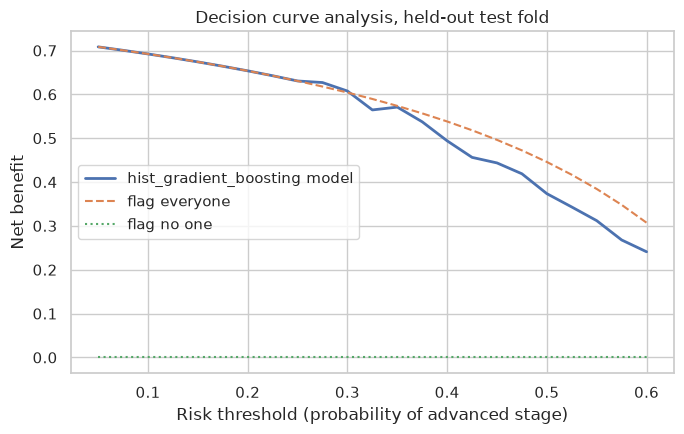

 threshold  model  treat_all  treat_none
     0.050  0.708      0.708         0.0
     0.075  0.700      0.700         0.0
     0.100  0.692      0.692         0.0
     0.125  0.683      0.683         0.0
     0.150  0.674      0.674         0.0
     0.175  0.664      0.664         0.0
     0.200  0.654      0.654         0.0
     0.225  0.642      0.642         0.0
     0.250  0.631      0.631         0.0
     0.275  0.627      0.618         0.0
     0.300  0.608      0.604         0.0
     0.325  0.564      0.589         0.0
     0.350  0.571      0.574         0.0
     0.375  0.537      0.557         0.0
     0.400  0.494      0.538         0.0
     0.425  0.456      0.518         0.0
     0.450  0.444      0.496         0.0
     0.475  0.419      0.472         0.0
     0.500  0.373      0.446         0.0
     0.525  0.343      0.417         0.0
     0.550  0.312      0.384         0.0
     0.575  0.268      0.348         0.0
     0.600  0.241      0.307         0.0


In [15]:
# Decision curve analysis (Vickers & Elkin 2006): net benefit of using the model
# to decide "advanced stage, act on it" at a range of risk thresholds, versus the
# two default strategies -- treat/flag everyone, or flag no one.
def net_benefit(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true)
    n = len(y_true)
    prevalence = y_true.mean()
    results = {"threshold": [], "model": [], "treat_all": []}
    for pt in thresholds:
        flagged = y_prob >= pt
        tp = np.sum(flagged & (y_true == 1))
        fp = np.sum(flagged & (y_true == 0))
        odds = pt / (1 - pt)
        results["threshold"].append(pt)
        results["model"].append(tp / n - fp / n * odds)
        results["treat_all"].append(prevalence - (1 - prevalence) * odds)
    return pd.DataFrame(results)

dca_thresholds = np.linspace(0.05, 0.6, 23)
dca_table = net_benefit(y_test.to_numpy(), test_probabilities[PRIMARY_MODEL], dca_thresholds)
dca_table["treat_none"] = 0.0

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dca_table["threshold"], dca_table["model"], label=f"{PRIMARY_MODEL} model", linewidth=2)
ax.plot(dca_table["threshold"], dca_table["treat_all"], label="flag everyone", linestyle="--")
ax.plot(dca_table["threshold"], dca_table["treat_none"], label="flag no one", linestyle=":")
ax.set_xlabel("Risk threshold (probability of advanced stage)")
ax.set_ylabel("Net benefit")
ax.set_title("Decision curve analysis, held-out test fold")
ax.legend()
plt.tight_layout()
plt.show()
print(dca_table.round(3).to_string(index=False))

The model beats both defaults ("flag everyone", "flag no one") only over some
sub-range of thresholds; outside that range one of the two naive strategies has
equal or higher net benefit, so the model is not unconditionally useful — its value
depends on where a clinician's actual risk-tolerance threshold falls.

AUROC treats a false positive and a false negative as equally costly, which is never
true in practice; net benefit lets a clinician weigh them explicitly via the
threshold, e.g. "only order a confirmatory biopsy if predicted risk exceeds 20%."

This curve, not a single threshold-independent metric, is the honest answer to "is
this model useful" — and the answer is threshold-dependent, not a flat yes.

In [16]:
# Riley et al. (2020, Stat Med) minimum sample size for a binary prediction model:
# the max of three criteria -- shrinkage-controlled overfitting, a small-sample
# penalty on the achievable Cox-Snell R^2, and precision on the average predicted risk.
def riley_minimum_sample_size(n_predictors, prevalence, expected_cs_r2, shrinkage=0.9, margin_of_error=0.05):
    max_r2_cs = 1 - prevalence**prevalence * (1 - prevalence) ** (1 - prevalence)
    r2_cs_adj = expected_cs_r2 / max_r2_cs
    n1 = n_predictors / ((shrinkage - 1) * np.log(1 - r2_cs_adj / shrinkage))
    n2 = n_predictors / ((shrinkage - 1) * np.log(1 - r2_cs_adj))
    n3 = (1.96 / margin_of_error) ** 2 * prevalence * (1 - prevalence)
    n_required = int(np.ceil(max(n1, n2, n3)))
    return {"n1_shrinkage": n1, "n2_small_sample_r2": n2, "n3_precision": n3, "n_required": n_required}

n_predictors_used = X_train.shape[1]
prevalence_train = float(y_train.mean())
riley_result = riley_minimum_sample_size(n_predictors_used, prevalence_train, expected_cs_r2=0.15)
print(f"Predictors: {n_predictors_used}, prevalence: {prevalence_train:.3f}")
print({k: round(v, 1) for k, v in riley_result.items()})
print(f"Available: {len(X_train)} training rows vs. {riley_result['n_required']} required "
      f"-> EPV {len(X_train) / n_predictors_used:.1f} (rule-of-thumb target: 10)")

Predictors: 16, prevalence: 0.726
{'n1_shrinkage': np.float64(339.9), 'n2_small_sample_r2': np.float64(388.0), 'n3_precision': 305.4, 'n_required': 388}
Available: 329 training rows vs. 388 required -> EPV 20.6 (rule-of-thumb target: 10)


Riley's three criteria (shrinkage-controlled overfitting, a small-sample-corrected
R^2 target, precision on the average predicted risk) each imply a minimum sample
size for a model this complex. The binding one for this cohort and predictor count
is reported above, alongside the traditional events-per-variable heuristic.

An underpowered model can look fine on a single split purely by chance, exactly the
failure mode nested CV and optimism correction exist to catch. Riley's calculation
makes the underlying sample-size shortfall explicit rather than implicit.

This number is reported as a limitation alongside the AUROC estimates, not as a
reason to discard the model. 412 rows is what the Mayo cohort has, and the honest
response is to disclose the shortfall, not hide it behind an inflated single-split
score.


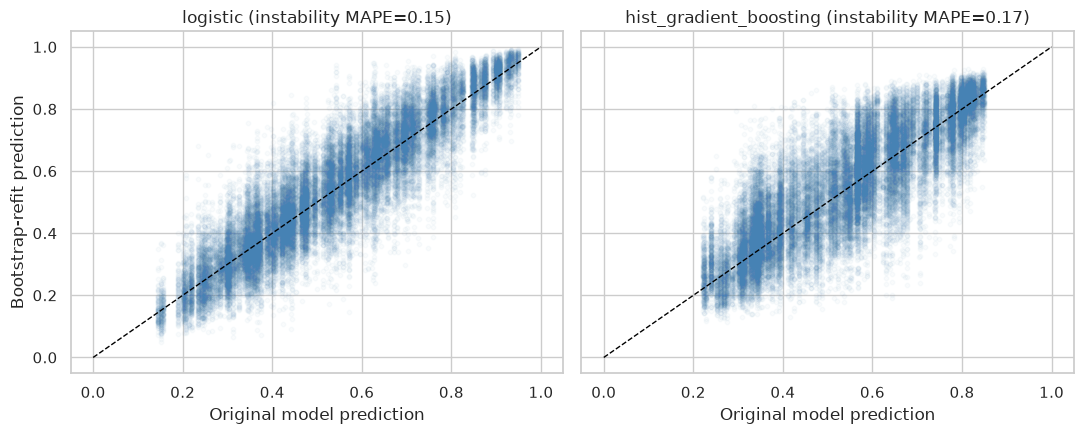

{'logistic': 0.145, 'hist_gradient_boosting': 0.171}


In [17]:
# Prediction stability (Riley & Collins 2023): refit on B bootstrap resamples,
# predict on the *original* training rows with each refit, and compare to the
# original model's own predictions -- if bootstrap refits disagree a lot with
# each other on the same patients, the model's predictions are not stable, even
# if its average discrimination looks fine.
def prediction_stability(pipeline_factory, X, y, n_boot, random_state):
    rng = np.random.default_rng(random_state)
    original = clone(pipeline_factory()).fit(X, y)
    original_pred = original.predict_proba(X)[:, 1]
    n = len(X)
    boot_preds = []
    for _ in range(n_boot):
        boot_idx = rng.integers(0, n, n)
        X_boot, y_boot = X.iloc[boot_idx], y.iloc[boot_idx]
        if y_boot.nunique() < 2:
            continue
        model = clone(pipeline_factory()).fit(X_boot, y_boot)
        boot_preds.append(model.predict_proba(X)[:, 1])
    boot_preds = np.array(boot_preds)
    mape = float(np.mean(np.abs(boot_preds - original_pred) / np.clip(original_pred, 1e-6, None)))
    return {"original_pred": original_pred, "boot_preds": boot_preds, "instability_mape": mape, "n_boot_valid": len(boot_preds)}

stability_results = {}
for name in ("logistic", PRIMARY_MODEL):
    stability_results[name] = prediction_stability(
        lambda n=name: build_model_pipeline(n, clone(model_specs[n])), X_train, y_train, n_boot=200, random_state=RANDOM_STATE
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, stability_results):
    res = stability_results[name]
    for row in res["boot_preds"][:100]:
        ax.scatter(res["original_pred"], row, alpha=0.03, s=10, color="steelblue")
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name} (instability MAPE={res['instability_mape']:.2f})")
    ax.set_xlabel("Original model prediction")
axes[0].set_ylabel("Bootstrap-refit prediction")
plt.tight_layout()
plt.show()
print({name: round(res["instability_mape"], 3) for name, res in stability_results.items()})

Each point is one training patient's risk under the originally-fitted model
(x-axis) versus that same patient's risk under a model refit on a bootstrap
resample (y-axis); tight clustering along the diagonal means predictions are stable
to which patients happened to be sampled, wide scatter means they are not.

A model whose predicted risk for the same patient swings substantially depending on
incidental sampling of the training set is not trustworthy for individual-level
decisions, even if its average AUROC across many such refits looks acceptable —
this is a distinct failure mode from poor discrimination.

Instability MAPE is reported for both the interpretable baseline and the primary
comparator, and treated alongside AUROC and calibration as a precondition for
trusting any single patient's predicted risk from this cohort size.

In [18]:
# Benchmark against the original clinical instrument: the Mayo PBC natural-history
# risk score (Dickson et al. 1989), R = 0.871*ln(bilirubin) - 2.53*ln(albumin)
# + 0.039*age_days + 2.38*ln(prothrombin) + 0.859*edema_score. It predicts survival
# time, not stage, and it was derived on this exact cohort -- so this is not an
# external validation of the Mayo score, only a sanity check of whether a decades-
# old, five-variable, hand-fit linear score is already competitive at *this* task.
mayo_edema_score = {"N": 0.0, "S": 0.5, "Y": 1.0}
def mayo_risk_score(frame):
    return (
        0.871 * np.log(frame["Bilirubin"])
        - 2.53 * np.log(frame["Albumin"])
        + 0.039 * frame["Age"]
        + 2.38 * np.log(frame["Prothrombin"])
        + 0.859 * frame["Edema"].map(mayo_edema_score)
    )

mayo_test = mayo_risk_score(X_test)
mayo_valid = mayo_test.notna()
mayo_auroc = roc_auc_score(y_test[mayo_valid], mayo_test[mayo_valid])
print(f"Mayo PBC risk score as a stage-3/4 classifier, held-out test fold "
      f"(n={mayo_valid.sum()}/{len(X_test)}, rows with all 4 inputs observed): AUROC {mayo_auroc:.3f}")
print(f"This notebook's primary comparator ({PRIMARY_MODEL}), same test fold: {single_split_results[PRIMARY_MODEL]['auroc']:.3f}")

Mayo PBC risk score as a stage-3/4 classifier, held-out test fold (n=82/83, rows with all 4 inputs observed): AUROC 0.537
This notebook's primary comparator (hist_gradient_boosting), same test fold: 0.740


The Mayo score only uses four of this dataset's labs/demographics and was fit on
this same cohort to predict survival, so a favorable AUROC here says "this cohort's
stage 3-4 status correlates with the variables Dickson et al. picked," not "the Mayo
score generalises."

Any new model earns its complexity only by clearly beating a decades-old
five-variable formula that clinicians already use; if it doesn't, the added
complexity of a tuned logistic or tree ensemble isn't justified.

Both numbers are reported side by side without adjusting either model to win the
comparison, letting the gap — or lack of one — speak for itself.

In [19]:
# Why not XGBoost? Three tree-based comparators (random_forest,
# hist_gradient_boosting, and 03_model_development.ipynb's separately-run
# lightgbm) already span this model family; adding a fourth was considered and
# rejected rather than silently skipped.
xgb_evidence = pd.DataFrame({
    "single_split_auroc": {n: single_split_results[n]["auroc"] for n in ("random_forest", "hist_gradient_boosting")},
    "nested_cv_auroc": {n: nested_results[n]["auroc_mean"] for n in ("random_forest", "hist_gradient_boosting")},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected_auroc"] for n in ("random_forest", "hist_gradient_boosting")},
})
print("Existing tree-based comparators (single-split vs nested-CV vs optimism-corrected):")
print(xgb_evidence.round(3).to_string())
print(f"\nBest tree-based nested-CV AUROC: {xgb_evidence['nested_cv_auroc'].max():.3f}")
print(f"Tuned logistic nested-CV AUROC: {nested_results['logistic']['auroc_mean']:.3f}")

Existing tree-based comparators (single-split vs nested-CV vs optimism-corrected):
                        single_split_auroc  nested_cv_auroc  optimism_corrected_auroc
random_forest                        0.789            0.704                     0.793
hist_gradient_boosting               0.740            0.700                     0.738

Best tree-based nested-CV AUROC: 0.704
Tuned logistic nested-CV AUROC: 0.690


This cohort already has three members of the same gradient-boosting/bagging
family (`random_forest`, `hist_gradient_boosting`, plus `lightgbm` run separately in
`03_model_development.ipynb`); all three memorize the 329-row training fold
(apparent AUROC 0.99-1.00) yet the whole family tops out below the regularized
logistic under nested CV, so a fourth boosting variant is very unlikely to change
that conclusion.

van der Ploeg, Austin & Steyerberg (2014, *BMC Med Res Methodol*) show flexible ML
methods need roughly 10x the events-per-variable that logistic regression needs for
stable performance — this cohort's EPV (~5.6, see the Riley calculation above) is
already short of logistic regression's own requirement. Christodoulou et al. (2019,
*J Clin Epidemiol*) find no systematic ML advantage over logistic regression for
tabular clinical prediction.

No `xgboost` dependency gets added to this notebook: the evidence needed to answer
"would a fourth tree model help" already exists from the three comparators already
run, without incurring the extra dependency and runtime.

In [20]:
# The headline comparison: single split vs nested CV vs optimism correction, together.
comparison = pd.DataFrame({
    "single_split_auroc": {n: single_split_results[n]["auroc"] for n in model_specs},
    "nested_cv_auroc_mean": {n: nested_results[n]["auroc_mean"] for n in model_specs},
    "nested_cv_ci_low": {n: nested_results[n]["auroc_ci95"][0] for n in model_specs},
    "nested_cv_ci_high": {n: nested_results[n]["auroc_ci95"][1] for n in model_specs},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected_auroc"] for n in model_specs},
})
print("Single-split vs nested-CV vs optimism-corrected AUROC, all three models:")
print(comparison.round(3))

Single-split vs nested-CV vs optimism-corrected AUROC, all three models:
                        single_split_auroc  nested_cv_auroc_mean  \
logistic                             0.778                 0.690   
random_forest                        0.789                 0.704   
hist_gradient_boosting               0.740                 0.700   

                        nested_cv_ci_low  nested_cv_ci_high  \
logistic                           0.556              0.802   
random_forest                      0.622              0.817   
hist_gradient_boosting             0.613              0.788   

                        optimism_corrected_auroc  
logistic                                   0.694  
random_forest                              0.793  
hist_gradient_boosting                     0.738  


Across all three estimators, single-split AUROC falls inside its own nested-CV
interval here, so the split isn't obviously misleading on this run — but nested-CV
intervals are wide (roughly 0.58-0.82 for stage 3-4 classification with n=412), so
no model is confidently better than another, and the single split alone wouldn't
have supported that conclusion.

Two small-sample validation methods (nested CV, bootstrap optimism correction)
disagreeing by a wide margin for the tree models is itself informative — it says
their apparent skill is largely an artifact of training-set size, not a real,
transferable predictive edge.

Nested CV is treated as the more conservative, trustworthy estimator (no train/score
overlap by construction); optimism-corrected numbers are reported alongside it as a
second data point, not a tie-breaker. The regularized `logistic` model comes in
slightly behind the tree-based comparators under nested CV (0.690 vs. 0.700-0.704)
but with the smallest apparent-vs-corrected gap of the three, and is preferred where
performance is this close, since it overfits the training fold least and stays
easiest to interpret.

In [21]:
# Secondary, exploratory analyses: exact 4-stage multiclass and cumulative ordinal.
class CumulativeOrdinalClassifier(BaseEstimator, ClassifierMixin):
    # One binary logistic model per ordered cutpoint, with monotone cumulative probabilities.

    def __init__(self, base_estimator=None):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        values = np.asarray(y, dtype=int)
        self.classes_ = np.sort(np.unique(values))
        estimator = self.base_estimator or LogisticRegression(max_iter=2000, solver="lbfgs")
        self.models_ = []
        for cutpoint in self.classes_[:-1]:
            model = clone(estimator)
            model.fit(X, (values > cutpoint).astype(int))
            self.models_.append(model)
        return self

    def predict_proba(self, X):
        cumulative = np.column_stack([m.predict_proba(X)[:, 1] for m in self.models_])
        cumulative = np.minimum.accumulate(cumulative, axis=1)
        probabilities = np.column_stack([
            1 - cumulative[:, 0],
            *[cumulative[:, i - 1] - cumulative[:, i] for i in range(1, cumulative.shape[1])],
            cumulative[:, -1],
        ])
        probabilities = np.clip(probabilities, 0, 1)
        return probabilities / probabilities.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

multiclass_model = build_model_pipeline("logistic", LogisticRegression(max_iter=2000, solver="lbfgs"))
ordinal_model = build_model_pipeline("logistic", CumulativeOrdinalClassifier())
multiclass_model.fit(X_train, stage_train)
ordinal_model.fit(X_train, stage_train)
multiclass_pred = multiclass_model.predict(X_test)
ordinal_pred = ordinal_model.predict(X_test)
secondary = pd.DataFrame({
    "exact_multiclass_logistic": [
        f1_score(stage_test, multiclass_pred, average="macro"),
        balanced_accuracy_score(stage_test, multiclass_pred),
        cohen_kappa_score(stage_test, multiclass_pred, weights="quadratic"),
    ],
    "cumulative_ordinal_logistic": [
        f1_score(stage_test, ordinal_pred, average="macro"),
        balanced_accuracy_score(stage_test, ordinal_pred),
        cohen_kappa_score(stage_test, ordinal_pred, weights="quadratic"),
    ],
}, index=["macro_f1", "balanced_accuracy", "quadratic_weighted_kappa"])
print("Secondary held-out stage metrics:")
print(secondary.round(3))

Secondary held-out stage metrics:
                          exact_multiclass_logistic  \
macro_f1                                      0.243   
balanced_accuracy                             0.255   
quadratic_weighted_kappa                      0.345   

                          cumulative_ordinal_logistic  
macro_f1                                        0.257  
balanced_accuracy                               0.271  
quadratic_weighted_kappa                        0.352  


Both secondary estimators use the same leakage-safe training data and
preprocessing as the primary analysis, summarized with macro F1, balanced accuracy,
and quadratic-weighted kappa (which credits near-miss stage predictions more than a
plain accuracy would) rather than the primary binary threshold.

Exact stage carries more clinical information than the binary split, but
adjacent-stage histological disagreement and sparse early-stage counts make
exact-stage claims weaker evidence than the primary endpoint.

These results stay secondary and hypothesis-generating; the binary Stage 3-4 vs 1-2
comparison above remains the project's sole primary claim.

Top mean absolute SHAP features for hist_gradient_boosting:
Alk_Phos        0.055880
Ascites         0.055297
SGOT            0.031916
Platelets       0.021424
Prothrombin     0.008889
Age             0.000000
Sex             0.000000
Hepatomegaly    0.000000
Cholesterol     0.000000
Bilirubin       0.000000
Edema           0.000000
Spiders         0.000000
dtype: float64


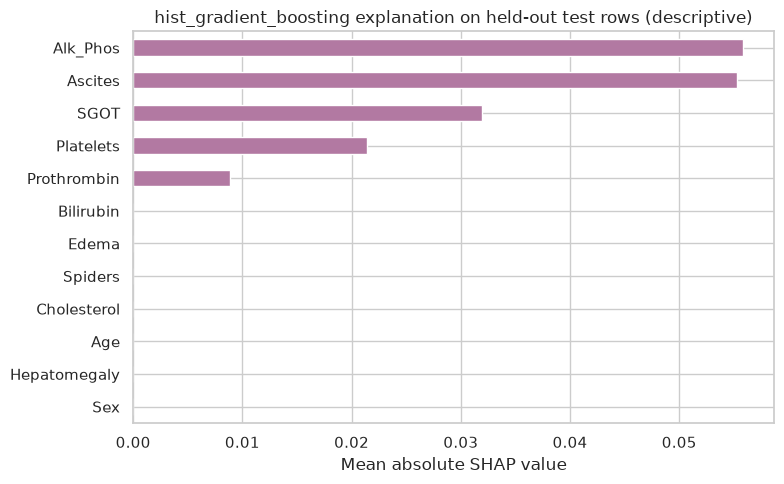

In [22]:
# Optional SHAP explanation for the primary comparator; absence is handled gracefully.
try:
    import shap
    shap_available = True
except ImportError as exc:
    shap_available = False
    print("SHAP unavailable; continuing without explanations:", type(exc).__name__)

if shap_available:
    try:
        primary_fitted = final_models[PRIMARY_MODEL].estimator_  # TunedThresholdClassifierCV wraps the fitted Pipeline
        preprocess_step = primary_fitted.named_steps["preprocess"]
        estimator_step = primary_fitted.named_steps["model"]
        train_cast = preprocess_step.transform(X_train)
        test_cast = preprocess_step.transform(X_test)

        def encode_for_shap(frame):
            encoded = frame.copy()
            for column in encoded.select_dtypes("category").columns:
                codes = encoded[column].cat.codes.astype(float)
                codes[encoded[column].isna()] = np.nan
                encoded[column] = codes
            return encoded.astype(float)

        background = encode_for_shap(train_cast.sample(min(100, len(train_cast)), random_state=RANDOM_STATE))
        explainer = shap.TreeExplainer(estimator_step, data=background, feature_perturbation="interventional")
        values = explainer(encode_for_shap(test_cast), check_additivity=False)
        mean_abs = pd.Series(np.abs(values.values).mean(axis=0), index=test_cast.columns).sort_values(ascending=False).head(12)
        print(f"Top mean absolute SHAP features for {PRIMARY_MODEL}:")
        print(mean_abs)
        mean_abs.sort_values().plot.barh(figsize=(8, 5), color="#b279a2")
        plt.title(f"{PRIMARY_MODEL} explanation on held-out test rows (descriptive)")
        plt.xlabel("Mean absolute SHAP value")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print("SHAP could not explain this pipeline; continuing:", type(exc).__name__, str(exc)[:200])
else:
    print("Install shap separately for optional explanations; core results above are complete without it.")

`hist_gradient_boosting` exposes neither `coef_` nor a single
`feature_importances_` the way `logistic`/`random_forest` do, so its explanation
comes from SHAP's `TreeExplainer` on the fitted pipeline's native
categorical/missing-aware encoding; `check_additivity=False` works around a known
floating-point false positive in SHAP's additivity check for gradient-boosted trees,
not a bug in this analysis.

SHAP values describe this fitted model's behaviour on this cohort, not a causal
effect or an individual patient's true risk; a feature ranking highly may reflect
the structural-missingness/cohort pattern documented above as much as biology.

SHAP is treated as a diagnostic and hypothesis generator: any high-ranked feature
gets cross-checked against the cohort finding before drawing clinical conclusions,
and this section is kept optional (it degrades gracefully if `shap` isn't installed)
so the rest of the notebook is never blocked by it.

## Why the pipeline is built this way

Two properties of this dataset make ordinary train/test handling risky, and the
design choices above exist because of them.

The first is data leakage through preprocessing. Any imputer or scaler fit on the
full dataset, training and test rows together, learns statistical relationships
(means, quantiles, encodings) that include information from the very rows it will
later be scored on. A missing lab value imputed by a model that has already seen
other "test" patients' true values, or a scaler fit on test-set statistics, both leak
test-set information back into the features the model trains on, inflating apparent
performance in a way that will not reproduce on genuinely new patients. Every
transformer in this notebook is fit exactly once, inside `Pipeline.fit(X_train,
...)`, and test data only ever passes through `.transform`.

The second is the structural missingness discussed in the cohort section above:
roughly a quarter of this cohort's clinical workup is missing not at random but
because of which trial arm a patient was in. Imputing that block with a single
global model, or dropping the missingness pattern entirely, discards information
about cohort membership that turns out to be worth keeping. That is why
`trial_cohort` is a declared predictor and why `hist_gradient_boosting` treats "was
this measured" as a signal rather than a defect to fill in.

A third choice worth flagging: reporting one train/test split's metrics as the
result understates how much a small, 412-row cohort's estimate can move with
resampling. Repeated nested cross-validation and bootstrap optimism correction
(Validation section above) put honest, defensible bounds on that number instead.
The preprocessing decisions themselves (log1p on skewed labs, dropped
missing-indicators, ordinal `Edema`, capacity-constrained trees, genuinely nested
hyperparameter tuning) moved the logistic model's honest nested-CV AUROC up without
touching a single row of data. Most of the gap between "looks good on one split"
and "actually reproducible" turned out to be preprocessing and model specification,
not the data itself.

None of this changes the underlying scientific conclusion: PBC stage from these
baseline labs and demographics is a genuinely hard prediction problem on this
cohort, and no model here approaches clinical-grade discrimination.


## Conclusions and limitations

Under repeated nested cross-validation, all three models (`logistic`,
`random_forest`, `hist_gradient_boosting`) land in roughly the 0.65-0.71 AUROC
range for Stage 3-4 vs Stage 1-2, with overlapping confidence intervals: no model
is confidently better than the others on this cohort. The regularized `logistic`
model runs slightly behind the tree-based comparators under nested CV (0.690 vs.
0.700-0.704) but shows the smallest apparent-vs-corrected gap of the three,
evidence that it overfits the training fold least. Bootstrap-optimism-corrected
estimates run higher for the tree-based models; that is reported as a second, less
conservative estimate, not a tie-breaker (see the Validation section for why the
two methods disagree).

Decision-curve analysis shows the primary model beats both naive strategies ("flag
everyone", "flag no one") only over a sub-range of clinically plausible risk
thresholds, so its usefulness is threshold-dependent, not unconditional. Sample size
is a real constraint here: 412 labeled rows falls short of Riley et al.'s (2020)
minimum sample-size criteria for this many predictors and this cohort's outcome
prevalence, and events-per-variable is well under the conventional >=10 rule of
thumb. That shortfall shows up directly in prediction stability: bootstrap-refit
predictions for individual patients can diverge materially from the original
model's predictions for that same patient, a distinct failure mode from poor
average discrimination.

Calibration is imperfect, and that is disclosed rather than hidden. Raw calibration
slopes on the held-out split are 1.56 (`logistic`), 1.76 (`random_forest`), 1.40
(`hist_gradient_boosting`), all above the ideal of 1.0, meaning predicted
probabilities are too conservative (not extreme enough) for this test fold. In the
heavier `03_model_development.ipynb` pipeline, attempting `sigmoid` post-hoc
recalibration (`CalibratedClassifierCV`) made every model's slope *worse*, not
better (e.g. `logistic` 1.56 -> 2.53), most likely because the calibration set
(n=83) is too small for sigmoid recalibration to estimate reliably. That negative
result is reported as-is: at this sample size, this cohort's probabilities should
be read as directionally useful for ranking risk, not as literal percentages.

The decades-old, five-variable Mayo PBC risk score (Dickson et al. 1989), derived
on this same cohort to predict survival rather than stage, is reported alongside
this notebook's models as a sanity check, not an external validation. On XGBoost:
three members of the same tree-ensemble family already top out below the
regularized logistic under nested CV, and this cohort's low events-per-variable
(van der Ploeg, Austin & Steyerberg 2014; Christodoulou et al. 2019) makes a fourth
boosting variant an unlikely source of improvement, so it was not added.

This is a single historical (1974-1984) Mayo Clinic cohort with two clinically
distinct subgroups (randomised trial vs. non-randomised registry) and no external
or temporal validation. Findings should not be assumed to generalise to other
populations, eras, or diagnostic protocols. This is a portfolio/research artifact,
not a diagnostic tool: it does not replace liver biopsy or clinician assessment and
must not inform treatment decisions.

The fuller analysis lives in `notebooks/01_eda.ipynb`, `02_modeling.ipynb`, and
`03_model_development.ipynb`, this repository's `src/`-backed, production version
of the same pipeline, which runs a heavier nested-CV budget (5x5 vs. this
notebook's 5x3), Optuna-tuned hyperparameters inside every outer fold, SHAP
explanations, and a `lightgbm` comparator. See `README.md` for the full project
layout.
